In [1]:
pip install git+https://github.com/mario-akira/cic_compensator.git

  Cloning https://github.com/mario-akira/cic_compensator.git to /tmp/pip-req-build-0773zko2
  Running command git clone --filter=blob:none --quiet https://github.com/mario-akira/cic_compensator.git /tmp/pip-req-build-0773zko2
  Resolved https://github.com/mario-akira/cic_compensator.git to commit 1603916fe1c634b4dd1fac37506f5057f43274b3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for cic_compensator: filename=cic_compensator-0.0.0-py3-none-any.whl size=4299 sha256=6f1132d5887743437ec3874f36307419eff80623f29108cb4e42e3b96ce3d922
  Stored in directory: /tmp/pip-ephem-wheel-cache-8myzlu2b/wheels/23/e3/73/861373dff82715a19a289176046a35f871ae733ceae8d4b614
Successfully built cic_compensator


In [2]:
from cic_compensator import FilterManager, CICFIRConfig

In [8]:
# 1. Configure your filter parameters here!
cfg = CICFIRConfig(
    R=25,     # Decimation CIC
    N=12,     # Stages CIC
    M=4,      # Decimation and phases FIR
    taps=72,  # Number of cofficients FIR
    fs=100e6  # Aquisition frequency
  )

In [9]:
# 2. Initializing the class
manager = FilterManager(cfg)

In [11]:
# 3. Configuring another FIR filter parameters
f_pass = 500e3
gain_db = 3
coeffs = manager.build(f_pass=f_pass, gain_db=gain_db)

print(f"Filter generated with {len(coeffs)} taps.")

Filter generated with 72 taps.


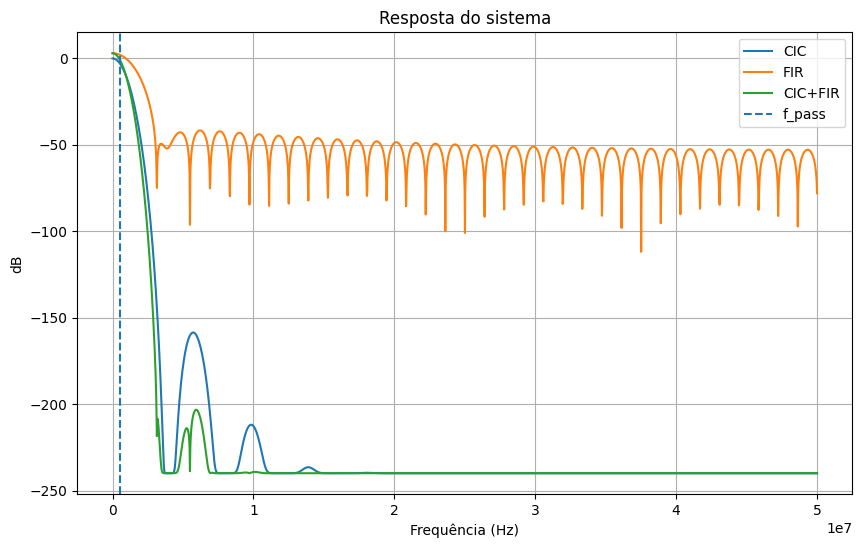

In [13]:
# 4. Simulating and seeing the results
manager.show_results(f_pass=f_pass)

In [14]:
# 5. Exporting a verilog implementation of the project
print("Generating verilog file...")
manager.export_hardware("filtro_teste.v")
print("Success, you filter file was created")

Generating verilog file...
Verilog gerado: filtro_teste.v
Success, you filter file was created
